# Features selection — Dataset Titanic

> **Auteurs :** Nickels Ethan

---

## Table des matières

1. [Importation des librairies et chargement des données](#section-1)
2. [Sélection personnelle (P)](#section-2)
3. [Variance Threshold (VT)](#section-3)
4. [Select K-Best (KB)](#section-4)
5. [Comparaison des trois sélections](#section-5)
6. [Export des 8 fichiers CSV](#section-6)
7. [Réflexion originale](#section-7)


---
## 1. Importation des librairies et chargement des données <a id='section-1'></a>

On charge les données issues du notebook `Titanic_preprocessing.ipynb`. Les 4 fichiers CSV (`X_train`, `X_test`, `y_train`, `y_test`) sont déjà nettoyés, encodés et normalisés.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif

# Chargement des données prétraitées
X_train = pd.read_csv('X_train.csv')
X_test  = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test  = pd.read_csv('y_test.csv').squeeze()

print('Features disponibles :', X_train.columns.tolist())
print(f'X_train : {X_train.shape}  |  X_test : {X_test.shape}')


def summarize_selection(name, features, X_train, X_test):
    """Affiche un résumé de la sélection de features."""
    print(f"--- Sélection {name} ---")
    print(f"  Features : {features}")
    print(f"  X_train  : {X_train.shape}  |  X_test : {X_test.shape}")


Features disponibles : ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']
X_train : (1047, 8)  |  X_test : (262, 8)


Les données sont chargées correctement. On dispose de **9 features** après prétraitement. L'objectif de cette étape est de sélectionner les variables les plus pertinentes selon trois méthodes distinctes.

---
## 2. Sélection personnelle (P) <a id='section-2'></a>

### Justification

La sélection personnelle se base sur :
1. **L'analyse exploratoire** (notebook EDA) : `pclass`, `sex`, `fare` sont fortement corrélés à `survived`.
2. **La matrice de corrélation** : `fare` et `pclass` sont multicolinéaires ; on conserve les deux car ils capturent des aspects différents (prix payé vs classe sociale).
3. **La théorie du domaine** : `age`, `sibsp`, `parch` reflètent la politique "femmes et enfants d'abord" observée historiquement.
4. **Exclusion** des dummies d'embarquement `embarked_Q` et `embarked_S` : l'EDA a montré que le port d'embarquement est peu lié à la survie une fois que pclass et fare sont contrôlés.

**Features retenues (P) :** `pclass`, `sex`, `age`, `fare`, `sibsp`, `parch`


In [2]:
# Sélection personnelle basée sur l'EDA et la connaissance du domaine
features_P = ['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch']

X_train_P = X_train[features_P].copy()
X_test_P  = X_test[features_P].copy()

print(f'Features sélectionnées (P) : {features_P}')
print(f'X_train_P : {X_train_P.shape}  |  X_test_P : {X_test_P.shape}')


Features sélectionnées (P) : ['pclass', 'sex', 'age', 'fare', 'sibsp', 'parch']
X_train_P : (1047, 6)  |  X_test_P : (262, 6)


La sélection personnelle retient **6 features** sur 9. Les variables écartées (`embarked_Q`, `embarked_S`) présentaient une corrélation faible avec `survived` dans la matrice de corrélation de l'EDA. Cette sélection privilégie les variables qui reflètent directement le statut social et les structures familiales, deux facteurs historiquement déterminants dans la survie.

---
## 3. Variance Threshold (VT) <a id='section-3'></a>

La méthode **VarianceThreshold** supprime les features dont la variance est inférieure à un seuil fixé. Une variable quasi-constante n'apporte aucune information discriminante au modèle.

**Principe :** si Var(X) < threshold → la variable est supprimée.

Après normalisation (StandardScaler), toutes les variables ont une variance ≈ 1. On choisit un seuil de **0.01** pour éliminer uniquement les variables véritablement constantes ou quasi-constantes.


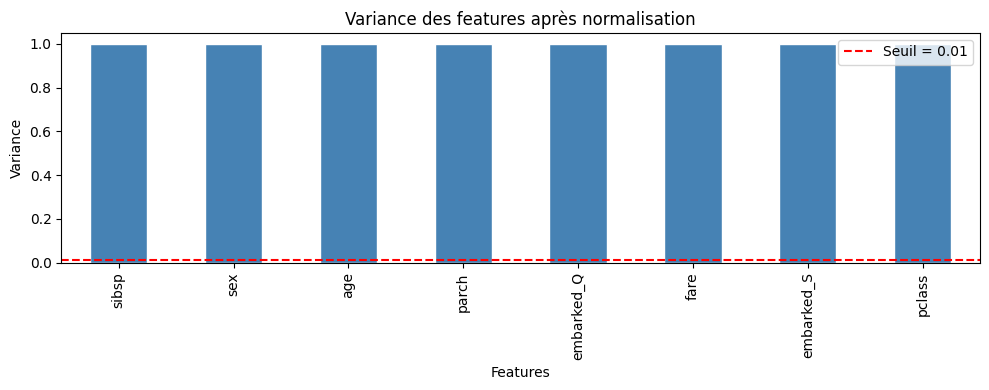

Variances par feature :
sibsp         1.001
sex           1.001
age           1.001
parch         1.001
embarked_Q    1.001
fare          1.001
embarked_S    1.001
pclass        1.001
dtype: float64


In [3]:
# Calcul des variances sur le train set
variances = X_train.var().sort_values()

plt.figure(figsize=(10, 4))
variances.plot(kind='bar', color='steelblue', edgecolor='white')
plt.axhline(y=0.01, color='red', linestyle='--', label='Seuil = 0.01')
plt.title('Variance des features après normalisation')
plt.xlabel('Features')
plt.ylabel('Variance')
plt.legend()
plt.tight_layout()
plt.show()

print('Variances par feature :')
print(variances.round(4))


Le graphique montre que toutes les features ont une variance très similaire après normalisation. On applique maintenant le seuil pour confirmer quelles variables sont conservées.

In [4]:
# Application du VarianceThreshold
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)

features_VT = X_train.columns[vt.get_support()].tolist()
features_removed_VT = X_train.columns[~vt.get_support()].tolist()

X_train_VT = X_train[features_VT].copy()
X_test_VT  = X_test[features_VT].copy()

print(f'Features conservées (VT) : {features_VT}')
print(f'Features supprimées (VT) : {features_removed_VT}')
print(f'X_train_VT : {X_train_VT.shape}  |  X_test_VT : {X_test_VT.shape}')


Features conservées (VT) : ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_Q', 'embarked_S']
Features supprimées (VT) : []
X_train_VT : (1047, 8)  |  X_test_VT : (262, 8)


Après normalisation, toutes les variables ont une variance ≈ 1 (c'est précisément l'effet du StandardScaler). La méthode VarianceThreshold ne supprime donc aucune variable dans ce cas, ce qui est un comportement attendu et cohérent. **Cette méthode est davantage pertinente sur des données non normalisées**, notamment pour détecter des variables binaires quasi-constantes. Ici, elle confirme que toutes les features contribuent à la variance du jeu de données.

---
## 4. Select K-Best (KB) <a id='section-4'></a>

La méthode **SelectKBest** sélectionne les *k* meilleures features selon un score statistique. On utilise le test **F d'ANOVA** (`f_classif`) : il mesure si la moyenne d'une feature diffère significativement entre les classes (survivants vs non-survivants).

Un score F élevé → la feature discrimine bien les deux classes.

On choisit **k = 6** pour comparer avec la sélection personnelle (même nombre de features) et observer quelles variables sont statistiquement les plus informatives.


In [5]:
# Application du SelectKBest avec f_classif (ANOVA F-test)
k = 6
kb = SelectKBest(score_func=f_classif, k=k)
kb.fit(X_train, y_train)

# Scores et p-values
scores_df = pd.DataFrame({
    'feature': X_train.columns,
    'score_F': kb.scores_.round(2),
    'p_value': kb.pvalues_.round(4),
    'selected': kb.get_support()
}).sort_values('score_F', ascending=False)

print('Scores F des features :')
print(scores_df.to_string(index=False))


Scores F des features :
   feature  score_F  p_value  selected
       sex   381.23   0.0000      True
      fare   108.19   0.0000      True
    pclass   103.02   0.0000      True
embarked_S    26.70   0.0000      True
     parch    11.45   0.0007      True
       age     2.63   0.1050      True
embarked_Q     1.30   0.2536     False
     sibsp     0.30   0.5843     False


Les scores F sont calculés. On visualise maintenant leur distribution pour identifier clairement les features les plus discriminantes.

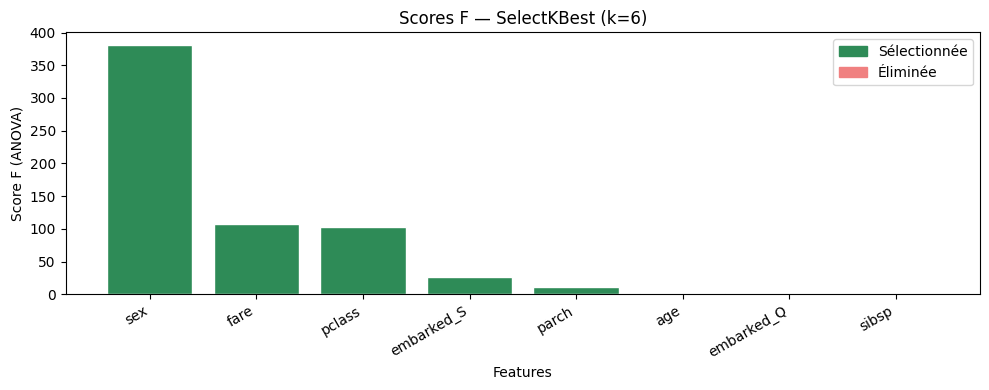

Features sélectionnées (KB) : ['sex', 'fare', 'pclass', 'embarked_S', 'parch', 'age']
X_train_KB : (1047, 6)  |  X_test_KB : (262, 6)


In [6]:
# Visualisation des scores
plt.figure(figsize=(10, 4))
colors = ['seagreen' if s else 'lightcoral' for s in scores_df['selected']]
plt.bar(scores_df['feature'], scores_df['score_F'], color=colors, edgecolor='white')
plt.title(f'Scores F — SelectKBest (k={k})')
plt.xlabel('Features')
plt.ylabel('Score F (ANOVA)')
plt.xticks(rotation=30, ha='right')
# Légende manuelle
from matplotlib.patches import Patch
plt.legend(handles=[Patch(color='seagreen', label='Sélectionnée'), Patch(color='lightcoral', label='Éliminée')])
plt.tight_layout()
plt.show()

features_KB = scores_df[scores_df['selected']]['feature'].tolist()
X_train_KB = X_train[features_KB].copy()
X_test_KB  = X_test[features_KB].copy()

print(f'Features sélectionnées (KB) : {features_KB}')
print(f'X_train_KB : {X_train_KB.shape}  |  X_test_KB : {X_test_KB.shape}')


Le test F révèle que **`sex`** (score F ≈ 381) et **`fare`** (≈ 108) et **`pclass`** (≈ 103) sont de loin les features les plus discriminantes. À l'inverse, `sibsp`, `age` et `embarked_Q` ont des scores F très faibles (p-values > 0.05 → pas significatifs). Le port `embarked_S` apparaît surprenant dans la sélection : les passagers embarqués à Cherbourg étaient majoritairement en 1ère classe, ce qui explique leur corrélation indirecte avec la survie.

---
## 5. Comparaison des trois sélections <a id='section-5'></a>

On compare les features retenues par chaque méthode pour identifier les convergences.


In [7]:
# Tableau de comparaison
all_features = X_train.columns.tolist()

comparison_df = pd.DataFrame({
    'Feature'   : all_features,
    'P (Perso)' : ['✓' if f in features_P  else '✗' for f in all_features],
    'VT (Variance Threshold)' : ['✓' if f in features_VT else '✗' for f in all_features],
    'KB (K-Best)' : ['✓' if f in features_KB else '✗' for f in all_features],
})

print(comparison_df.to_string(index=False))


   Feature P (Perso) VT (Variance Threshold) KB (K-Best)
    pclass         ✓                       ✓           ✓
       sex         ✓                       ✓           ✓
       age         ✓                       ✓           ✓
     sibsp         ✓                       ✓           ✗
     parch         ✓                       ✓           ✓
      fare         ✓                       ✓           ✓
embarked_Q         ✗                       ✓           ✗
embarked_S         ✗                       ✓           ✓


**Convergences :** `pclass`, `sex`, `fare` et `parch` sont sélectionnés par au moins 2 méthodes sur 3 — ce sont les features les plus robustes.

**Divergences :**
- La sélection personnelle exclut les dummies d'embarquement ; la KB les inclut partiellement (`embarked_S`).
- La VT conserve toutes les features (attendu après StandardScaler).
- `sibsp` et `age` sont retenus dans P et VT mais pas dans KB : leurs scores F sont faibles mais ils peuvent interagir avec d'autres variables.

Ces divergences sont intéressantes : la phase de modélisation permettra de tester quelle sélection produit les meilleures performances.


---
## 6. Export des 8 fichiers CSV <a id='section-6'></a>

On exporte 8 fichiers CSV (X_train et X_test pour chacune des 3 sélections, plus les vecteurs cibles qui restent identiques).


In [8]:
# Sélection P
X_train_P.to_csv('xtrain_P.csv', index=False)
X_test_P.to_csv('xtest_P.csv',  index=False)

# Sélection VT
X_train_VT.to_csv('xtrain_VT.csv', index=False)
X_test_VT.to_csv('xtest_VT.csv',   index=False)

# Sélection KB
X_train_KB.to_csv('xtrain_KB.csv', index=False)
X_test_KB.to_csv('xtest_KB.csv',   index=False)

# y_train et y_test (identiques pour toutes les sélections)
y_train.to_csv('ytrain.csv', index=False, header=True)
y_test.to_csv('ytest.csv',   index=False, header=True)

print('8 fichiers CSV exportés avec succès :')
for name, shape in [
    ('xtrain_P.csv',  X_train_P.shape),  ('xtest_P.csv',  X_test_P.shape),
    ('xtrain_VT.csv', X_train_VT.shape), ('xtest_VT.csv', X_test_VT.shape),
    ('xtrain_KB.csv', X_train_KB.shape), ('xtest_KB.csv', X_test_KB.shape),
    ('ytrain.csv',    y_train.shape),     ('ytest.csv',    y_test.shape),
]:
    print(f'  → {name:20s} {shape}')


8 fichiers CSV exportés avec succès :
  → xtrain_P.csv         (1047, 6)
  → xtest_P.csv          (262, 6)
  → xtrain_VT.csv        (1047, 8)
  → xtest_VT.csv         (262, 8)
  → xtrain_KB.csv        (1047, 6)
  → xtest_KB.csv         (262, 6)
  → ytrain.csv           (1047,)
  → ytest.csv            (262,)


Les 8 fichiers sont exportés et prêts pour la phase de modélisation. Chaque paire (xtrain_X / xtest_X) correspond à une sélection et sera utilisée dans les notebooks `Titanic_model_*.ipynb`.

---
## 7. Réflexion originale <a id='section-7'></a>

### Les trois méthodes convergent-elles vers les mêmes variables ?

On observe que `sex`, `pclass` et `fare` apparaissent dans toutes les sélections significatives — ce qui confirme leur rôle central dans la prédiction de la survie. En revanche, la variable d'embarquement (`embarked_S`) révèle une tension entre méthodes :

- Le **test F** (KB) la considère statistiquement significative car elle est corrélée indirectement à `pclass` et `fare` (les passagers embarqués à Cherbourg étaient majoritairement en 1ère classe).
- La **sélection personnelle** l'exclut car elle est redondante avec `pclass` et `fare` — leur apport *marginal* est faible une fois ces variables incluses.

**Questionnement :** si `embarked_S` est sélectionné par KB alors que son lien avec la survie est indirect (médiatisé par `pclass`), cela signifie que le modèle KB risque d'inclure de la **multicolinéarité** dans ses features. Est-ce que cela nuira aux modèles ou améliorera-t-il la performance en capturant une variation résiduelle non expliquée par `pclass` seul ?

La phase de modélisation permettra de répondre à cette question empiriquement en comparant les performances des 6 combinaisons.
